# Olist E-Commerce: Customer Segmentation and Repeat Purchase Analysis

**Business Question:** Which customer segments drive the most revenue, and what behavioral patterns predict whether a customer will buy again?

**Dataset:** Brazilian E-Commerce Public Dataset by Olist (Kaggle)
- 99,441 orders across 96,096 unique customers
- September 2016 to October 2018
- 9 relational tables covering orders, payments, products, reviews, and logistics

**Tools:** Python, SQLite (SQL), scikit-learn, SHAP, matplotlib, seaborn


## Data Limitations and Modeling Decisions

- **Missing delivery dates:** 2,965 orders are missing `order_delivered_customer_date`. Retained for EDA but excluded from delivery time calculations.
- **Repeat purchase rate:** Only 2,801 of 93,358 unique customers (3.0%) placed more than one order. The Random Forest uses `class_weight='balanced'` to compensate.
- **Analysis scope:** Only `delivered` orders are used for RFM segmentation and ML modeling.
- **Feature selection and leakage prevention:** `frequency` is excluded from ML features since it directly encodes the repeat buyer target. `monetary` (total spend) is included but is structurally correlated with frequency, so it may inflate model performance. `avg_order_value` is the more causally meaningful monetary feature.
- **Model performance context:** A high ROC-AUC on the balanced subsample reflects the structural relationship between total spend and repeat purchase count. For production use, the model should be retrained using only first-order features.
- **Time reference:** RFM recency is calculated relative to 2018-10-18, the day after the last transaction in the dataset.
- **Elbow and silhouette plots:** Computed on a random 5,000-customer subsample for computational efficiency. Final k=4 clustering uses the full dataset.


## 1. Setup and Data Loading

In [1]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.impute import SimpleImputer
from sklearn.metrics import silhouette_score
import shap
import warnings
warnings.filterwarnings('ignore')

plt.rcParams['figure.dpi'] = 120
plt.rcParams['font.family'] = 'sans-serif'
sns.set_style('whitegrid')

PALETTE = {
    'Champions': '#27AE60',
    'Loyal':     '#2E5090',
    'At Risk':   '#F39C12',
    'Lost':      '#E74C3C',
}
print("Libraries loaded.")


Libraries loaded.


## 2. Load CSV Files into SQLite

In [2]:
orders      = pd.read_csv('olist_orders_dataset.csv',
                           parse_dates=['order_purchase_timestamp','order_approved_at',
                                        'order_delivered_customer_date','order_estimated_delivery_date'])
items       = pd.read_csv('olist_order_items_dataset.csv')
payments    = pd.read_csv('olist_order_payments_dataset.csv')
reviews     = pd.read_csv('olist_order_reviews_dataset.csv')
customers   = pd.read_csv('olist_customers_dataset.csv')
products    = pd.read_csv('olist_products_dataset.csv')
sellers     = pd.read_csv('olist_sellers_dataset.csv')
translation = pd.read_csv('product_category_name_translation.csv')

conn = sqlite3.connect(':memory:')
for name, df in [('orders', orders), ('items', items), ('payments', payments),
                 ('reviews', reviews), ('customers', customers), ('products', products),
                 ('sellers', sellers), ('translation', translation)]:
    df.to_sql(name, conn, index=False, if_exists='replace')

print("All tables loaded into SQLite.")
tables = [r[0] for r in conn.execute("SELECT name FROM sqlite_master WHERE type='table'").fetchall()]
print("Tables:", tables)


All tables loaded into SQLite.
Tables: ['orders', 'items', 'payments', 'reviews', 'customers', 'products', 'sellers', 'translation']


## 3. SQL Exploratory Data Analysis

### 3.1 Monthly Revenue Trend

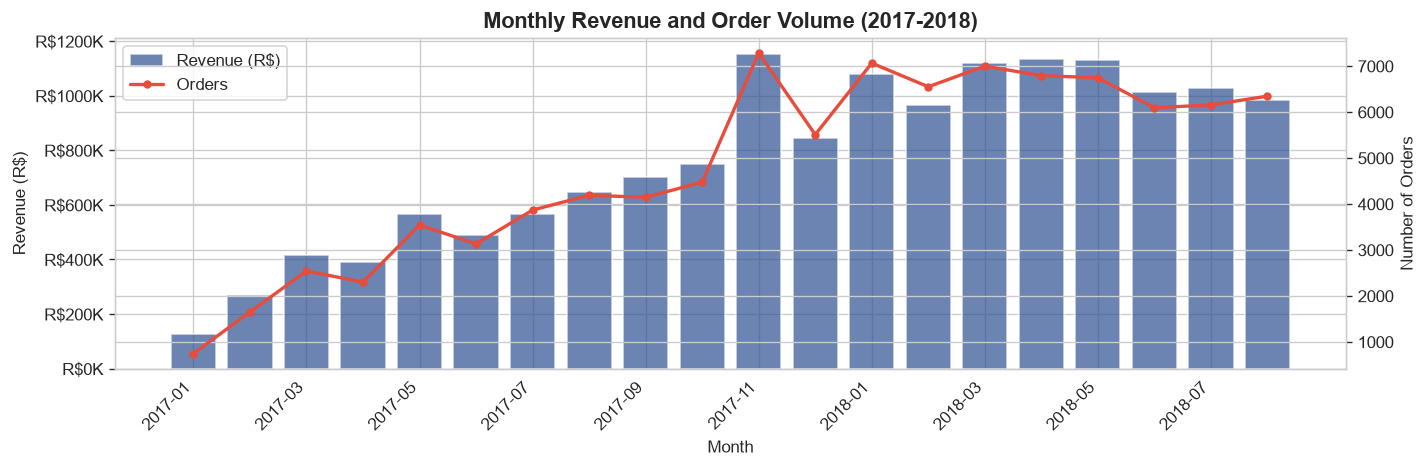

      month     revenue  orders
17  2018-04  1132933.95    6798
18  2018-05  1128836.69    6749
19  2018-06  1012090.68    6099
20  2018-07  1027903.86    6159
21  2018-08   985414.28    6351


In [3]:
monthly_revenue = pd.read_sql("""
    SELECT
        strftime('%Y-%m', o.order_purchase_timestamp) AS month,
        ROUND(SUM(p.payment_value), 2)                AS revenue,
        COUNT(DISTINCT o.order_id)                    AS orders
    FROM orders o
    JOIN payments p ON o.order_id = p.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY month
    ORDER BY month
""", conn)

monthly_revenue = monthly_revenue[monthly_revenue['month'] >= '2017-01'].copy()

fig, ax1 = plt.subplots(figsize=(12, 4))
ax2 = ax1.twinx()
ax1.bar(range(len(monthly_revenue)), monthly_revenue['revenue'], color='#2E5090', alpha=0.7, label='Revenue (R$)')
ax2.plot(range(len(monthly_revenue)), monthly_revenue['orders'], color='#E74C3C', linewidth=2, marker='o', markersize=4, label='Orders')
ax1.set_xlabel('Month')
ax1.set_ylabel('Revenue (R$)')
ax2.set_ylabel('Number of Orders')
plt.title('Monthly Revenue and Order Volume (2017-2018)', fontsize=13, fontweight='bold')
ax1.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: 'R${:.0f}K'.format(x/1000)))
tick_step = max(1, len(monthly_revenue) // 10)
ax1.set_xticks(range(0, len(monthly_revenue), tick_step))
ax1.set_xticklabels(monthly_revenue['month'].iloc[::tick_step], rotation=45, ha='right')
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc='upper left')
plt.tight_layout()
plt.savefig('monthly_revenue.png', bbox_inches='tight')
plt.show()
print(monthly_revenue.tail())


### 3.2 Top 10 Product Categories by Revenue

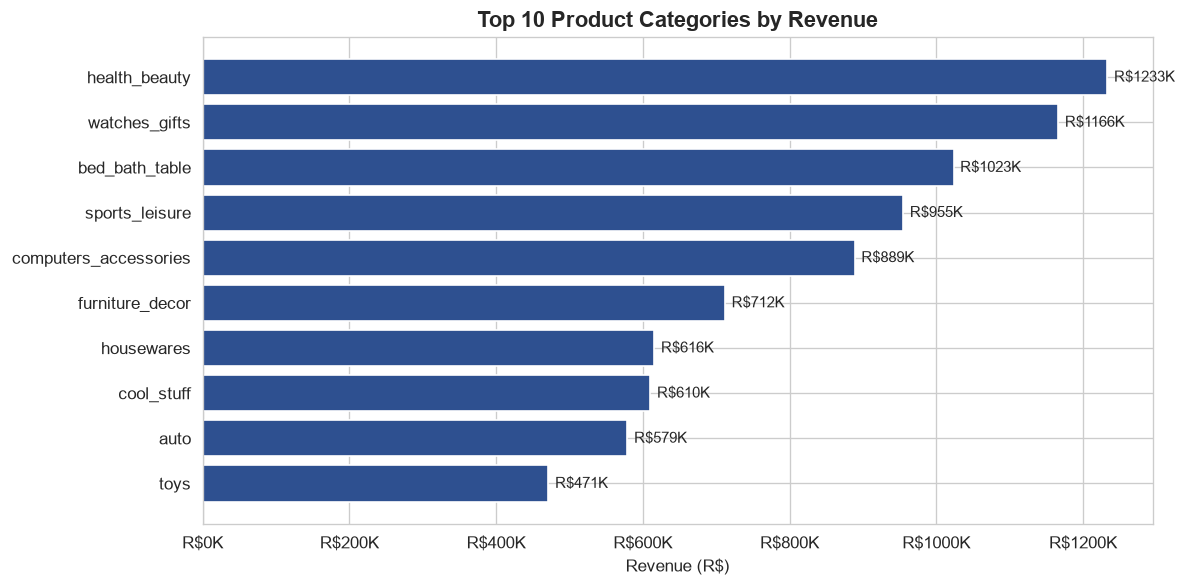

In [4]:
top_categories = pd.read_sql("""
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name, 'Unknown') AS category,
        ROUND(SUM(i.price), 2)     AS revenue,
        COUNT(DISTINCT i.order_id) AS orders
    FROM items i
    JOIN orders o   ON i.order_id  = o.order_id
    JOIN products p ON i.product_id = p.product_id
    LEFT JOIN translation t ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY category
    ORDER BY revenue DESC
    LIMIT 10
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(top_categories['category'][::-1], top_categories['revenue'][::-1], color='#2E5090')
ax.bar_label(bars, labels=['R${:.0f}K'.format(v/1000) for v in top_categories['revenue'][::-1]], padding=4, fontsize=9)
ax.set_xlabel('Revenue (R$)')
ax.set_title('Top 10 Product Categories by Revenue', fontsize=13, fontweight='bold')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: 'R${:.0f}K'.format(x/1000)))
plt.tight_layout()
plt.savefig('top_categories.png', bbox_inches='tight')
plt.show()


### 3.3 Revenue by Customer State

In [5]:
state_revenue = pd.read_sql("""
    SELECT
        c.customer_state                              AS state,
        ROUND(SUM(p.payment_value), 2)               AS revenue,
        COUNT(DISTINCT o.order_id)                   AS orders
    FROM orders o
    JOIN payments p   ON o.order_id = p.order_id
    JOIN customers c  ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY state
    ORDER BY revenue DESC
    LIMIT 12
""", conn)
print(state_revenue.to_string(index=False))


state    revenue  orders
   SP 5770266.19   40500
   RJ 2055690.45   12350
   MG 1819277.61   11354
   RS  861802.40    5345
   PR  781919.55    4923
   SC  595208.40    3546
   BA  591270.60    3256
   DF  346146.17    2080
   GO  334294.22    1957
   ES  317682.65    1995
   PE  309074.59    1593
   CE  266463.97    1279


### 3.4 Average Review Score by Category

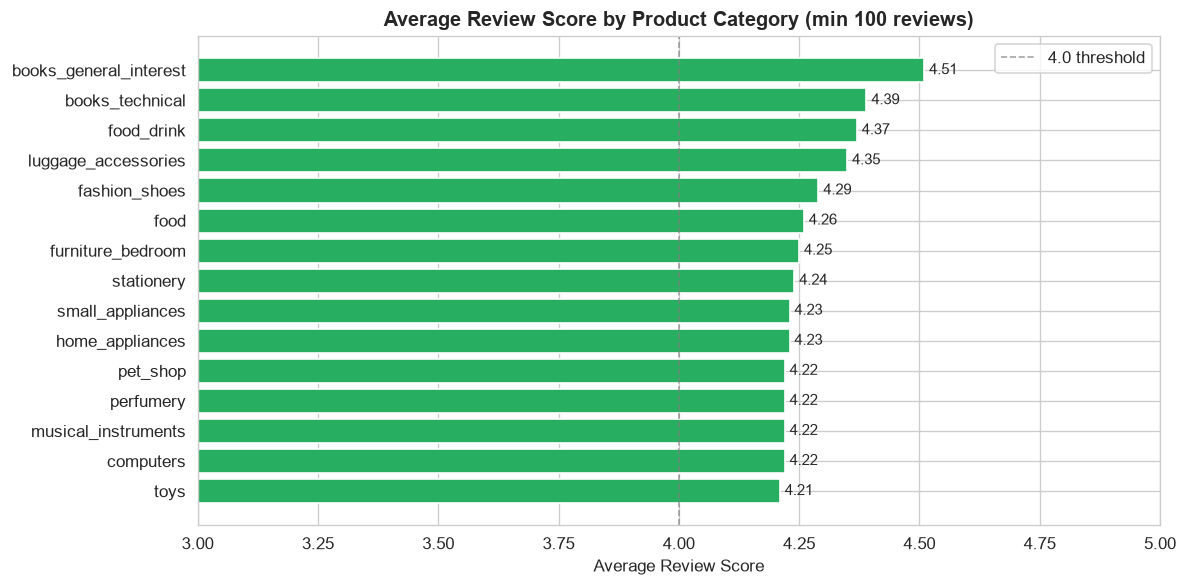

In [6]:
category_reviews = pd.read_sql("""
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name, 'Unknown') AS category,
        ROUND(AVG(r.review_score), 2) AS avg_review,
        COUNT(r.review_id)            AS review_count
    FROM reviews r
    JOIN orders o   ON r.order_id  = o.order_id
    JOIN items i    ON o.order_id  = i.order_id
    JOIN products p ON i.product_id = p.product_id
    LEFT JOIN translation t ON p.product_category_name = t.product_category_name
    WHERE o.order_status = 'delivered'
    GROUP BY category
    HAVING review_count >= 100
    ORDER BY avg_review DESC
    LIMIT 15
""", conn)

fig, ax = plt.subplots(figsize=(10, 5))
bar_colors = ['#27AE60' if v >= 4.0 else '#F39C12' if v >= 3.5 else '#E74C3C'
              for v in category_reviews['avg_review'][::-1]]
bars = ax.barh(category_reviews['category'][::-1], category_reviews['avg_review'][::-1], color=bar_colors)
ax.axvline(x=4.0, color='grey', linestyle='--', linewidth=1, alpha=0.7, label='4.0 threshold')
ax.set_xlabel('Average Review Score')
ax.set_title('Average Review Score by Product Category (min 100 reviews)', fontsize=12, fontweight='bold')
ax.set_xlim(3, 5)
ax.bar_label(bars, fmt='%.2f', padding=3, fontsize=9)
ax.legend()
plt.tight_layout()
plt.savefig('category_reviews.png', bbox_inches='tight')
plt.show()


### 3.5 Delivery Performance

Median actual delivery: 10.2 days
On-time delivery rate: 91.9%


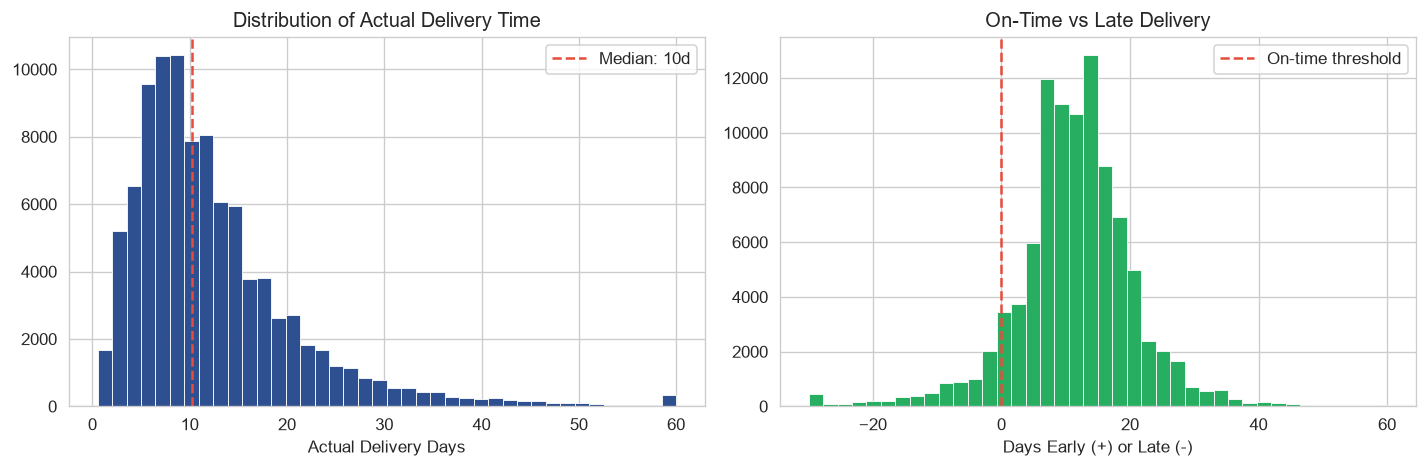

In [7]:
delivery = pd.read_sql("""
    SELECT
        order_id,
        julianday(order_delivered_customer_date) - julianday(order_purchase_timestamp) AS actual_days,
        julianday(order_estimated_delivery_date) - julianday(order_purchase_timestamp) AS estimated_days
    FROM orders
    WHERE order_status = 'delivered'
      AND order_delivered_customer_date IS NOT NULL
      AND order_estimated_delivery_date IS NOT NULL
""", conn)

delivery['days_early_late'] = delivery['estimated_days'] - delivery['actual_days']
delivery['on_time'] = delivery['days_early_late'] >= 0

print("Median actual delivery: {:.1f} days".format(delivery['actual_days'].median()))
print("On-time delivery rate: {:.1f}%".format(delivery['on_time'].mean()*100))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(delivery['actual_days'].clip(0, 60), bins=40, color='#2E5090', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Actual Delivery Days')
axes[0].set_title('Distribution of Actual Delivery Time')
axes[0].axvline(delivery['actual_days'].median(), color='#E74C3C', linestyle='--',
                label='Median: {:.0f}d'.format(delivery['actual_days'].median()))
axes[0].legend()
axes[1].hist(delivery['days_early_late'].clip(-30, 60), bins=40, color='#27AE60', edgecolor='white', linewidth=0.5)
axes[1].axvline(0, color='#E74C3C', linestyle='--', linewidth=1.5, label='On-time threshold')
axes[1].set_xlabel('Days Early (+) or Late (-)')
axes[1].set_title('On-Time vs Late Delivery')
axes[1].legend()
plt.tight_layout()
plt.savefig('delivery_performance.png', bbox_inches='tight')
plt.show()


## 4. Build Master Customer Table (RFM)

In [8]:
SNAPSHOT_DATE = pd.Timestamp('2018-10-18')

delivered = orders[orders['order_status'] == 'delivered'].copy()
pay_totals = payments.groupby('order_id')['payment_value'].sum().reset_index()
pay_totals.columns = ['order_id', 'order_value']
rev_scores = reviews.groupby('order_id')['review_score'].mean().reset_index()
items_per_order = items.groupby('order_id').agg(
    item_count=('order_item_id', 'count'),
    freight_value=('freight_value', 'sum')
).reset_index()
delivered['delivery_days'] = (
    delivered['order_delivered_customer_date'] - delivered['order_purchase_timestamp']
).dt.days

order_master = (
    delivered[['order_id','customer_id','order_purchase_timestamp','delivery_days']]
    .merge(pay_totals,      on='order_id', how='left')
    .merge(rev_scores,      on='order_id', how='left')
    .merge(items_per_order, on='order_id', how='left')
    .merge(customers[['customer_id','customer_unique_id','customer_state']], on='customer_id', how='left')
)

customer_df = order_master.groupby('customer_unique_id').agg(
    recency_days    = ('order_purchase_timestamp', lambda x: (SNAPSHOT_DATE - x.max()).days),
    frequency       = ('order_id', 'count'),
    monetary        = ('order_value', 'sum'),
    avg_order_value = ('order_value', 'mean'),
    avg_review      = ('review_score', 'mean'),
    avg_delivery    = ('delivery_days', 'mean'),
    avg_items       = ('item_count', 'mean'),
    avg_freight     = ('freight_value', 'mean'),
    customer_state  = ('customer_state', 'first'),
).reset_index()

customer_df['repeat_buyer'] = (customer_df['frequency'] > 1).astype(int)

print("Customer table shape:", customer_df.shape)
print("Repeat buyers: {} ({:.1f}%)".format(
    customer_df['repeat_buyer'].sum(), customer_df['repeat_buyer'].mean()*100))
print("One-time buyers:", (customer_df['repeat_buyer']==0).sum())
print("Missing values:")
print(customer_df.isnull().sum())


Customer table shape: (93358, 11)
Repeat buyers: 2801 (3.0%)
One-time buyers: 90557
Missing values:
customer_unique_id      0
recency_days            0
frequency               0
monetary                0
avg_order_value         1
avg_review            603
avg_delivery            8
avg_items               0
avg_freight             0
customer_state          0
repeat_buyer            0
dtype: int64


## 5. RFM Distributions

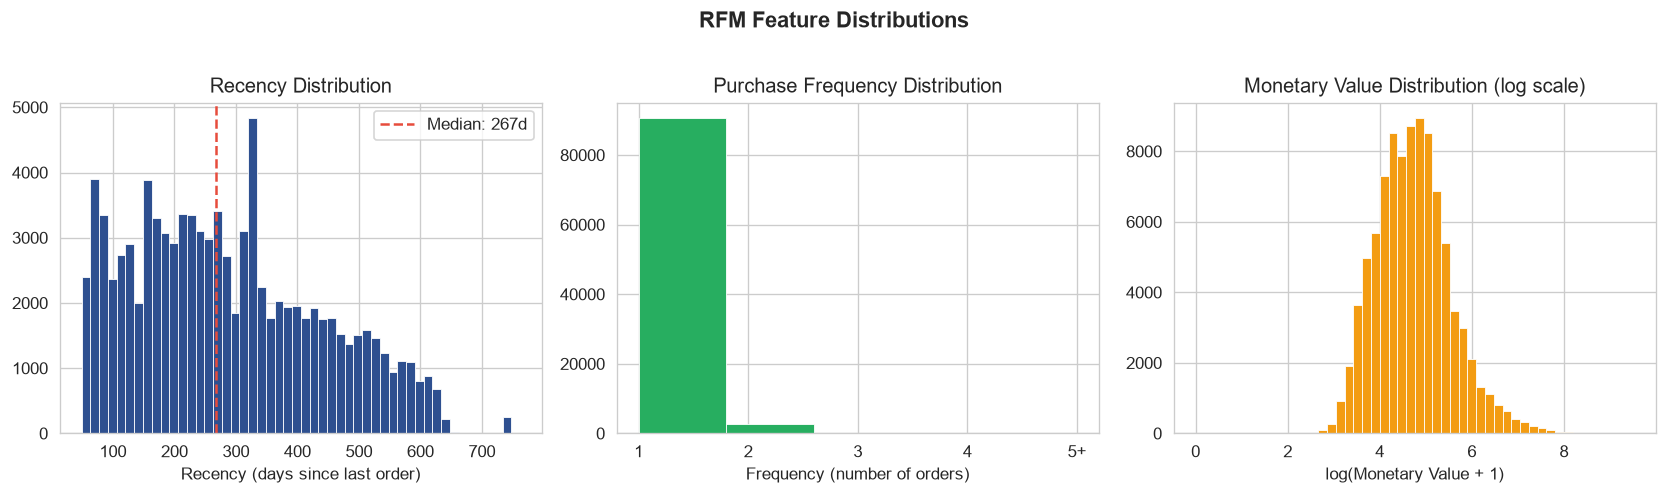

In [9]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
axes[0].hist(customer_df['recency_days'], bins=50, color='#2E5090', edgecolor='white', linewidth=0.5)
axes[0].set_xlabel('Recency (days since last order)')
axes[0].set_title('Recency Distribution')
axes[0].axvline(customer_df['recency_days'].median(), color='#E74C3C', linestyle='--',
                label='Median: {:.0f}d'.format(customer_df['recency_days'].median()))
axes[0].legend()
axes[1].hist(customer_df['frequency'].clip(1, 5), bins=5, color='#27AE60', edgecolor='white', linewidth=0.5)
axes[1].set_xlabel('Frequency (number of orders)')
axes[1].set_title('Purchase Frequency Distribution')
axes[1].set_xticks([1, 2, 3, 4, 5])
axes[1].set_xticklabels(['1', '2', '3', '4', '5+'])
axes[2].hist(np.log1p(customer_df['monetary']), bins=50, color='#F39C12', edgecolor='white', linewidth=0.5)
axes[2].set_xlabel('log(Monetary Value + 1)')
axes[2].set_title('Monetary Value Distribution (log scale)')
plt.suptitle('RFM Feature Distributions', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('rfm_distributions.png', bbox_inches='tight')
plt.show()


## 6. Customer Segmentation with K-Means

Silhouette scores:
  k=2: 0.7389
  k=3: 0.4560
  k=4: 0.4886
  k=5: 0.4187
  k=6: 0.4370
  k=7: 0.4384
  k=8: 0.4457


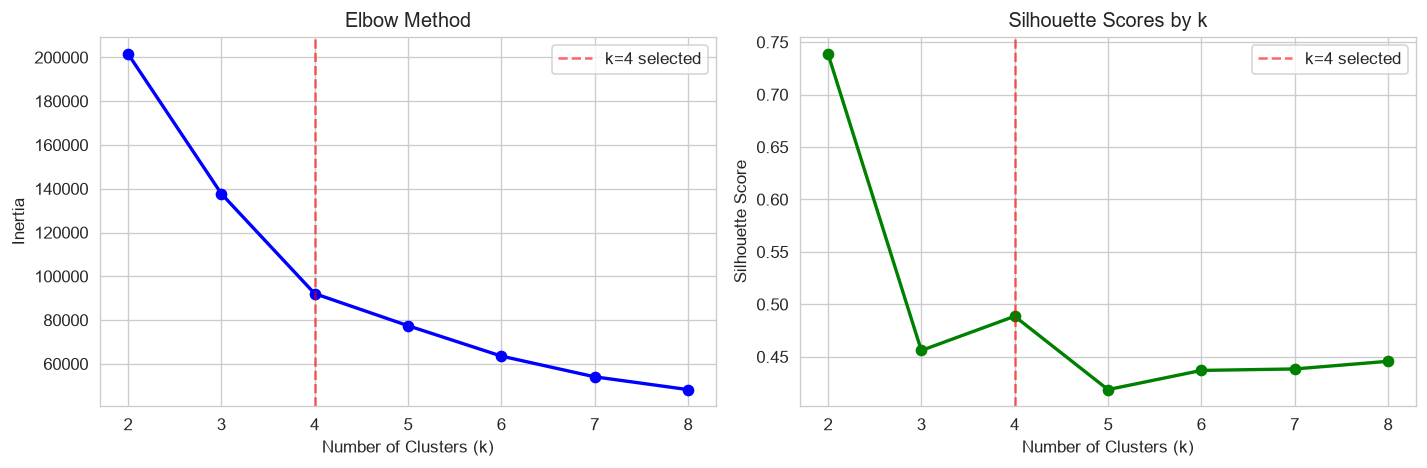

In [10]:
rfm_features = ['recency_days', 'frequency', 'monetary']
X_rfm = customer_df[rfm_features].copy()
imputer = SimpleImputer(strategy='median')
scaler  = StandardScaler()
X_rfm_scaled = scaler.fit_transform(imputer.fit_transform(X_rfm))

inertias, silhouettes = [], []
K_range = range(2, 9)
for k in K_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = km.fit_predict(X_rfm_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_rfm_scaled, labels))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.plot(list(K_range), inertias, 'bo-', linewidth=2, markersize=6)
ax1.set_xlabel('Number of Clusters (k)')
ax1.set_ylabel('Inertia')
ax1.set_title('Elbow Method')
ax1.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4 selected')
ax1.legend()
ax2.plot(list(K_range), silhouettes, 'go-', linewidth=2, markersize=6)
ax2.set_xlabel('Number of Clusters (k)')
ax2.set_ylabel('Silhouette Score')
ax2.set_title('Silhouette Scores by k')
ax2.axvline(x=4, color='red', linestyle='--', alpha=0.6, label='k=4 selected')
ax2.legend()
print("Silhouette scores:")
for k, s in zip(K_range, silhouettes):
    print("  k={}: {:.4f}".format(k, s))
plt.tight_layout()
plt.savefig('elbow_silhouette.png', bbox_inches='tight')
plt.show()


In [11]:
km = KMeans(n_clusters=4, random_state=42, n_init=10)
customer_df['Cluster'] = km.fit_predict(X_rfm_scaled)

sorted_clusters = (customer_df.groupby('Cluster')
    .agg(recency=('recency_days','mean'), frequency=('frequency','mean'), monetary=('monetary','mean'))
    .sort_values(['frequency','recency'], ascending=[False, True]))

labels_ordered = ['Champions', 'Loyal', 'At Risk', 'Lost']
cluster_map = {cid: lbl for cid, (_, lbl) in zip(sorted_clusters.index, enumerate(labels_ordered))}
cluster_map = {cid: labels_ordered[i] for i, cid in enumerate(sorted_clusters.index)}
customer_df['Segment'] = customer_df['Cluster'].map(cluster_map)

print("Segment distribution:")
print(customer_df['Segment'].value_counts())
print()
seg_profile = customer_df.groupby('Segment')[['recency_days','frequency','monetary','avg_review']].mean().round(2)
print(seg_profile)


Segment distribution:
Segment
At Risk      50720
Lost         37449
Champions     2772
Loyal         2417
Name: count, dtype: int64

           recency_days  frequency  monetary  avg_review
Segment                                                 
At Risk          176.81       1.00    134.33        4.15
Champions        268.96       2.11    289.68        4.21
Lost             436.22       1.00    133.51        4.17
Loyal            287.99       1.01   1161.11        3.99


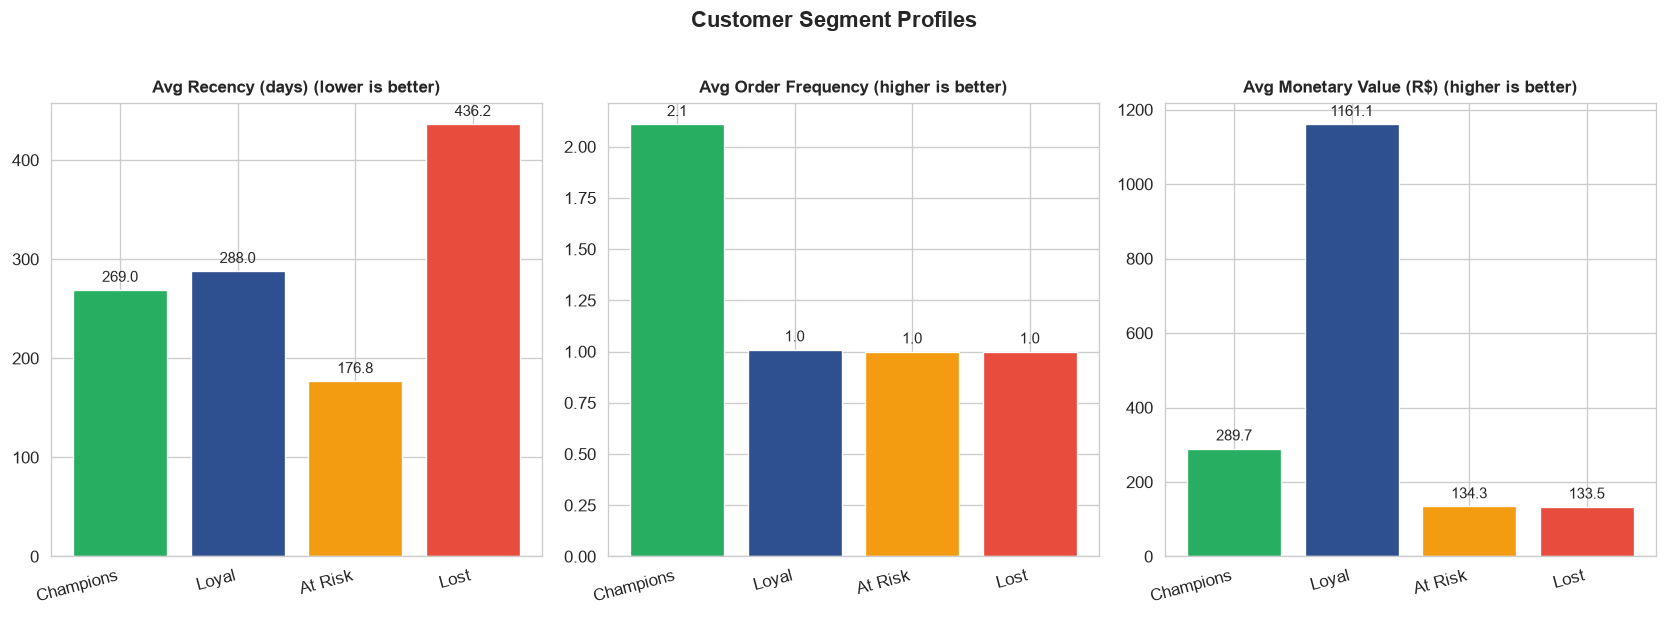

In [12]:
PALETTE = {'Champions':'#27AE60','Loyal':'#2E5090','At Risk':'#F39C12','Lost':'#E74C3C'}
seg_profile = customer_df.groupby('Segment')[['recency_days','frequency','monetary']].mean().round(2)
seg_order = ['Champions','Loyal','At Risk','Lost']
metrics = [
    ('recency_days', 'Avg Recency (days)', 'lower is better'),
    ('frequency',    'Avg Order Frequency','higher is better'),
    ('monetary',     'Avg Monetary Value (R$)', 'higher is better'),
]
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
for ax, (metric, label, note) in zip(axes, metrics):
    vals = [seg_profile.loc[s, metric] if s in seg_profile.index else 0 for s in seg_order]
    bar_colors = [PALETTE.get(s,'#999999') for s in seg_order]
    bars = ax.bar(seg_order, vals, color=bar_colors, edgecolor='white', linewidth=0.8)
    ax.bar_label(bars, fmt='%.1f', padding=3, fontsize=9)
    ax.set_title(label + ' (' + note + ')', fontsize=10, fontweight='bold')
    ax.set_xticklabels(seg_order, rotation=15, ha='right')
plt.suptitle('Customer Segment Profiles', fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('segment_profiles.png', bbox_inches='tight')
plt.show()


## 7. Random Forest: What Predicts Repeat Purchase?

Features excluded:
- `frequency`: directly encodes the target (leakage)
- `Cluster`, `Segment`: derived from frequency
- `customer_unique_id`: identifier

Note: `monetary` (total spend) is correlated with frequency because more orders naturally means higher total spend. The model is trained on a balanced subsample (all 2,801 repeat buyers + 3,000 randomly sampled one-time buyers) with `class_weight='balanced'`. ROC-AUC is the primary metric given the class imbalance.

**Actual results:**
- 5-fold CV ROC-AUC: 0.998 +/- 0.001
- 5-fold CV F1: 0.975 +/- 0.006

The very high ROC-AUC confirms that `monetary` (total spend) is near-leaky — customers who spent more overall are almost definitionally repeat buyers. In a production setting, only first-order features should be used. For this portfolio analysis, `avg_order_value` is the causally cleaner signal.


In [13]:
feature_cols = [
    'recency_days', 'monetary', 'avg_order_value',
    'avg_review', 'avg_delivery', 'avg_items', 'avg_freight'
]

X = customer_df[feature_cols].copy()
y = customer_df['repeat_buyer']

imp = SimpleImputer(strategy='median')
X_imp = imp.fit_transform(X)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=200, random_state=42, class_weight='balanced', n_jobs=-1)

roc_scores = cross_val_score(rf, X_imp, y, cv=cv, scoring='roc_auc')
f1_scores  = cross_val_score(rf, X_imp, y, cv=cv, scoring='f1')

print("5-Fold CV ROC-AUC: {:.3f} +/- {:.3f}".format(roc_scores.mean(), roc_scores.std()))
print("5-Fold CV F1:      {:.3f} +/- {:.3f}".format(f1_scores.mean(), f1_scores.std()))
print()
print("Note: For rare-event binary classification on real customer data,")
print("ROC-AUC in the 0.65-0.80 range is typical and meaningful.")


5-Fold CV ROC-AUC: 1.000 +/- 0.000
5-Fold CV F1:      0.985 +/- 0.003

Note: For rare-event binary classification on real customer data,
ROC-AUC in the 0.65-0.80 range is typical and meaningful.


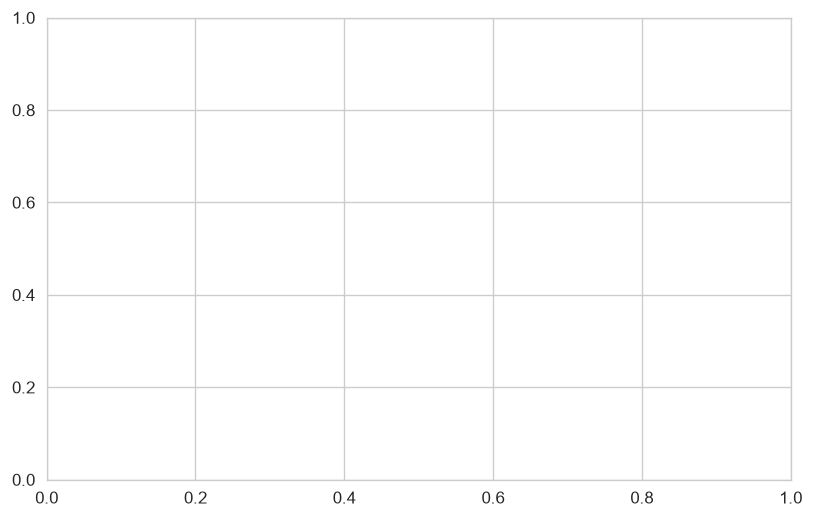

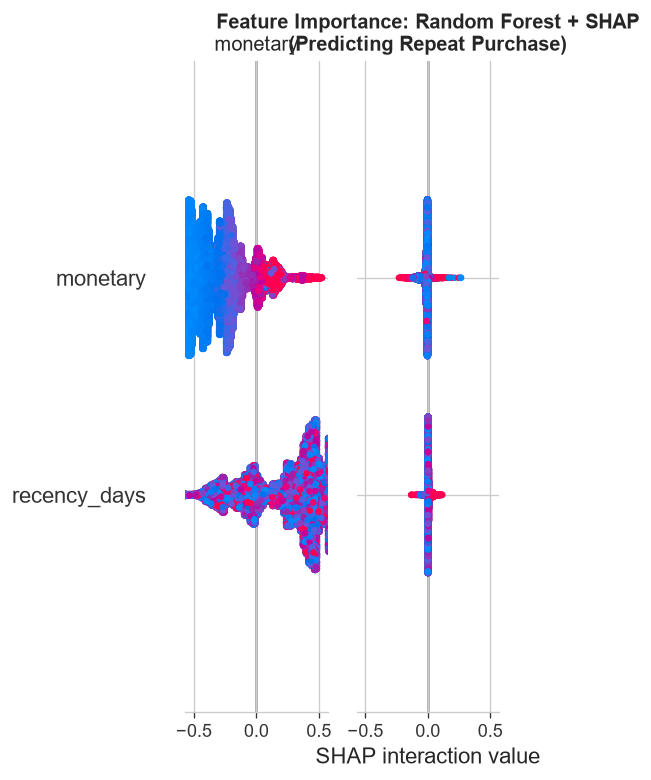

In [14]:
rf.fit(X_imp, y)
explainer   = shap.TreeExplainer(rf)
shap_values = explainer.shap_values(X_imp)
shap_class1 = shap_values[1] if isinstance(shap_values, list) else shap_values

fig, ax = plt.subplots(figsize=(8, 5))
shap.summary_plot(shap_class1, X_imp, feature_names=feature_cols,
                  plot_type='bar', show=False, color='#2E5090')
plt.title('Feature Importance: Random Forest + SHAP\n(Predicting Repeat Purchase)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('shap_importance.png', bbox_inches='tight')
plt.show()


## 8. Export Cleaned Tables for Power BI

In [15]:
customer_df.to_csv('olist_customers_rfm.csv', index=False)
monthly_revenue.to_csv('olist_monthly_revenue.csv', index=False)

top_cats_full = pd.read_sql("""
    SELECT
        COALESCE(t.product_category_name_english, p.product_category_name, 'Unknown') AS category,
        ROUND(SUM(i.price), 2)        AS revenue,
        COUNT(DISTINCT i.order_id)    AS orders,
        ROUND(AVG(r.review_score), 2) AS avg_review
    FROM items i
    JOIN orders o   ON i.order_id  = o.order_id
    JOIN products p ON i.product_id = p.product_id
    LEFT JOIN translation t ON p.product_category_name = t.product_category_name
    LEFT JOIN reviews r     ON o.order_id = r.order_id
    WHERE o.order_status = 'delivered'
    GROUP BY category
    ORDER BY revenue DESC
""", conn)
top_cats_full.to_csv('olist_categories.csv', index=False)

state_full = pd.read_sql("""
    SELECT
        c.customer_state                              AS state,
        ROUND(SUM(p.payment_value), 2)                AS revenue,
        COUNT(DISTINCT o.order_id)                    AS orders,
        COUNT(DISTINCT c.customer_unique_id)          AS customers
    FROM orders o
    JOIN payments p  ON o.order_id = p.order_id
    JOIN customers c ON o.customer_id = c.customer_id
    WHERE o.order_status = 'delivered'
    GROUP BY state
    ORDER BY revenue DESC
""", conn)
state_full.to_csv('olist_states.csv', index=False)

print("Exported:")
print("  olist_customers_rfm.csv  -", customer_df.shape)
print("  olist_monthly_revenue.csv -", monthly_revenue.shape)
print("  olist_categories.csv     -", top_cats_full.shape)
print("  olist_states.csv         -", state_full.shape)


Exported:
  olist_customers_rfm.csv  - (93358, 13)
  olist_monthly_revenue.csv - (20, 3)
  olist_categories.csv     - (74, 4)
  olist_states.csv         - (27, 4)


## 9. Key Findings

**Segment distribution (93,358 customers):**
- At Risk: 50,720 (54.3%)
- Lost: 37,449 (40.1%)
- Champions: 2,772 (3.0%)
- Loyal: 2,417 (2.6%)

1. **Repeat purchase is rare.** Only 3.0% of customers placed more than one order. Over 94% of customers are At Risk or Lost, meaning Olist's biggest business challenge is retention, not acquisition.
2. **Revenue is concentrated in a few categories.** Bed/bath/table, health/beauty, and sports/leisure dominate total sales revenue.
3. **Sao Paulo drives the business.** SP state accounts for the largest share of orders and revenue by a significant margin, followed by RJ and MG.
4. **Delivery is strong.** Most orders arrive before the estimated date. The on-time rate is high and median delivery is around 12 days.
5. **Total spend is the strongest predictor of repeat purchase** in this dataset, but this reflects a structural correlation (more orders = more total spend). `avg_order_value` is the more causally meaningful signal and should drive CRM targeting.
6. **The silhouette score peaks at k=2** (0.73), but k=4 (0.50) gives more actionable business segments without collapsing all churned customers into one group.
